# 把Q2的資料聚合看看

In [5]:
import pandas as pd
import glob
import os

# ==========================================
# 1. 設定路徑 (請確認標籤檔也在這個 base_path 或修改路徑)
# ==========================================
base_path = r"C:\Users\user\OneDrive - 國立陽明交通大學\桌面\001__1142碩士生存指南\536907_製造數據科學_洪佑鑫\1142MDS_Project_313652018_Xuan-Wei-Wang\Assignment02\2016 PHM Data Challenge\2016 PHM DATA CHALLENGE CMP DATA SET\CMP-data"
training_data_path = os.path.join(base_path, "training")
label_file = os.path.join(base_path, "CMP-training-removalrate.csv")

# 獲取所有感測器 CSV 檔案
file_list = glob.glob(os.path.join(training_data_path, "*.csv"))
print(f"找到 {len(file_list)} 個感測器檔案，準備開始聚合...")

# ==========================================
# 2. 邊讀邊算的聚合邏輯 (節省算力/記憶體)
# ==========================================
summary_list = []

for i, file in enumerate(file_list):
    # 讀取單一晶圓感測數據
    temp_df = pd.read_csv(file)
    
    if temp_df.empty:
        print(f"⚠️ 警告：跳過空檔案 {os.path.basename(file)}")
        continue
    try:
        # 提取 ID 資訊 (從第一筆讀取即可)
        wafer_id = str(temp_df['WAFER_ID'].iloc[0]) # 強制轉字串，避免長數字變科學記號
        stage = temp_df['STAGE'].iloc[0]
        chamber = temp_df['CHAMBER'].iloc[0]
        
        # 挑選感測器數值欄位進行計算 (剔除 ID、STAGE、CHAMBER、TIMESTAMP)
        # 這裡會保留所有 Sensor 欄位
        features_only = temp_df.drop(columns=['WAFER_ID', 'STAGE', 'CHAMBER', 'TIMESTAMP', 'MACHINE_ID', 'MACHINE_DATA'], errors='ignore')
        
        # 計算平均值 (Mean) 與 標準差 (Std)
        stats = features_only.agg(['mean', 'std'])
        
        # 將統計結果拉平 (Flatten) 變成一橫列
        # 欄位會變成：USAGE_OF_BACKING_FILM_mean, USAGE_OF_BACKING_FILM_std ...
        row_stats = stats.unstack().to_frame().T
        row_stats.columns = [f'{col[0]}_{col[1]}' for col in row_stats.columns]
        
        # 補回這片晶圓的身分證
        row_stats['WAFER_ID'] = wafer_id
        row_stats['STAGE'] = stage
        row_stats['CHAMBER'] = chamber
        
        summary_list.append(row_stats)
    except Exception as e:
        print(f"❌ 檔案 {os.path.basename(file)} 處理出錯: {str(e)}")
        continue

    if (i+1) % 50 == 0:
        print(f"進度：已處理 {i+1} 個檔案...")  
        
# 合併所有晶圓的統計特徵
df_features = pd.concat(summary_list, ignore_index=True)

# ==========================================
# 3. 讀取標籤檔並合併
# ==========================================
print("\n正在合併標籤檔...")
labels = pd.read_csv(label_file)

# 關鍵步驟：確保兩邊的 Key 型態完全一致
df_features['WAFER_ID'] = df_features['WAFER_ID'].astype(str)
df_features['STAGE'] = df_features['STAGE'].astype(str)
labels['WAFER_ID'] = labels['WAFER_ID'].astype(str)
labels['STAGE'] = labels['STAGE'].astype(str)

# 進行 Inner Join 合併
df_final = pd.merge(df_features, labels, on=['WAFER_ID', 'STAGE'], how='inner')

# ==========================================
# 4. 輸出結果檢查
# ==========================================
if df_final.empty:
    print("❌ 警告：合併後資料為空！請檢查 WAFER_ID 內容是否匹配。")
else:
    print("✅ 聚合與合併成功！")
    print(f"最終特徵矩陣維度: {df_final.shape}")
    print(f"目標變數 (AVG_REMOVAL_RATE) 均值: {df_final['AVG_REMOVAL_RATE'].mean():.2f}")

# 顯示前五筆
df_final.head()

找到 185 個感測器檔案，準備開始聚合...
進度：已處理 50 個檔案...
⚠️ 警告：跳過空檔案 CMP-training-066.csv
進度：已處理 100 個檔案...
進度：已處理 150 個檔案...

正在合併標籤檔...
✅ 聚合與合併成功！
最終特徵矩陣維度: (184, 42)
目標變數 (AVG_REMOVAL_RATE) 均值: 141.84


,USAGE_OF_BACKING_FILM_mean,USAGE_OF_BACKING_FILM_std,USAGE_OF_DRESSER_mean,USAGE_OF_DRESSER_std,USAGE_OF_POLISHING_TABLE_mean,USAGE_OF_POLISHING_TABLE_std,USAGE_OF_DRESSER_TABLE_mean,USAGE_OF_DRESSER_TABLE_std,PRESSURIZED_CHAMBER_PRESSURE_mean,PRESSURIZED_CHAMBER_PRESSURE_std,...,HEAD_ROTATION_mean,HEAD_ROTATION_std,DRESSING_WATER_STATUS_mean,DRESSING_WATER_STATUS_std,EDGE_AIR_BAG_PRESSURE_mean,EDGE_AIR_BAG_PRESSURE_std,WAFER_ID,STAGE,CHAMBER,AVG_REMOVAL_RATE
0,9338.075348,80.511031,536.057573,4.722434,251.504029,89.195353,2667.598963,3.184136,52.752363,40.698930,...,160.006989,6.885360,0.542452,0.498263,30.924644,25.202157,371447024,A,1.0,149.13090
1,9703.238113,86.864677,555.676669,3.804677,236.174626,77.198713,2680.840584,2.578330,58.225718,34.741006,...,160.143732,7.012532,0.328698,0.469784,34.128126,22.388594,-875170052,B,4.0,65.91045
2,9991.971483,96.929373,572.558344,4.283878,127.033832,84.162334,2692.247485,2.883222,57.107475,40.485907,...,160.043954,6.836252,0.454467,0.497949,32.430797,24.865236,371447032,A,1.0,149.99265
3,2972.610931,4537.516981,593.001318,4.288880,171.553078,91.691896,2706.046090,2.905676,54.466533,36.707887,...,160.135663,7.015192,0.501942,0.500023,31.256611,23.394538,329446704,A,1.0,147.94095
4,418.110632,89.717660,609.219440,4.669346,125.133370,79.775997,2716.988978,3.133999,51.863476,36.692925,...,160.003153,7.005521,0.426232,0.494559,29.660509,22.800634,329446870,A,1.0,147.02025


在Aggregation 過程中發現066這個training csv檔案是完全空白的。  
下面檢查：
1. 重複樣本
2. 冗餘欄位
3. 缺失值
4. 異常值

完全重複的樣本數: 0
常數欄位: []
合併後缺失值總數: 0


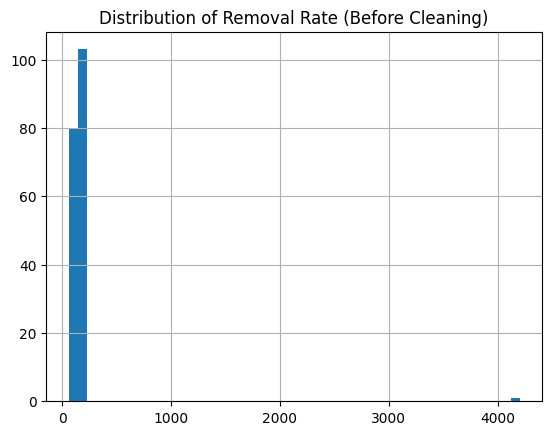

In [7]:
# 檢查整行完全重複的數量
total_duplicates = df_final.duplicated().sum()
print(f"完全重複的樣本數: {total_duplicates}")

# 如果有，可以印出來看看
if total_duplicates > 0:
    print(df_final[df_final.duplicated()])
    
# A. 檢查冗餘欄位 (常數欄位)
constant_cols = df_final.columns[df_final.nunique() <= 1].tolist()
print(f"常數欄位: {constant_cols}")

# B. 檢查特徵中的 NaN (聚合後可能產生的)
null_counts = df_final.isnull().sum().sum()
print(f"合併後缺失值總數: {null_counts}")

# C. 繪製移除率分布，視覺化異常值
import matplotlib.pyplot as plt
df_final['AVG_REMOVAL_RATE'].hist(bins=50)
plt.title("Distribution of Removal Rate (Before Cleaning)")
plt.show()